<a href="https://colab.research.google.com/github/FlyAIBox/langchain-academy/blob/fly101/module-4/research-assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/research-assistant.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239974-lesson-4-research-assistant)

# 研究助理（Research Assistant）

## 回顾

本节将用到 LangGraph 的几个核心主题：

- 记忆（Memory）
- 人机协同（Human-in-the-loop）
- 可控性（Controllability）

现在，我们把这些理念整合起来，构建一个非常常见且实用的 AI 应用：研究自动化。

传统研究通常由分析师承担，工作繁琐、耗时。AI 在这方面有很大助力空间。

但研究环节需要强定制化：直接使用大模型原始输出，往往不适合真实的决策流程。

基于 AI 的定制化「研究与报告生成」工作流，是一个可行且有前景的方向（参考：[Reports over RAG](https://jxnl.co/writing/2024/06/05/predictions-for-the-future-of-rag/#reports-over-rag)）。

## 目标

构建一个围绕聊天模型的「轻量级多智能体」系统，用于定制化研究流程。

`数据源选择（Source Selection）`
- 用户可以自由选择任意研究输入源。

`规划（Planning）`
- 用户给出主题，系统生成一支 AI 分析师团队，每位分析师负责一个子主题。
- 在研究开始前，通过「人机协同」来微调/确认这些子主题。

`大模型使用（LLM Utilization）`
- 每位分析师会基于所选数据源，与专家型 AI 进行深入「访谈」。
- 访谈为多轮对话，旨在抽取更具体、更有洞见的信息（类似于 [STORM](https://arxiv.org/abs/2402.14207) 论文中的做法）。
- 这些访谈将使用带有内部状态的 `子图（sub-graphs）` 来承载与追踪。

`研究过程（Research Process）`
- 专家会并行收集信息以回答分析师的问题（`parallel`）。
- 所有访谈将通过 `map-reduce` 同步进行与汇总。

`输出格式（Output Format）`
- 将每次访谈中得到的洞见进行综合，产出最终报告。
- 报告使用可定制提示词，便于灵活调整输出格式。

![Screenshot 2024-08-26 at 7.26.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb164d61c93d48e604091_research-assistant1.png)

In [ ]:
%%capture --no-stderr
# 安装项目所需的Python包
# 使用 %%capture --no-stderr 来隐藏安装过程中的输出信息，保持notebook整洁
# %pip install --quiet -U langgraph langchain_openai langchain_community langchain_core tavily-python wikipedia
%pip install --quiet langgraph==0.6.7 langchain_openai==0.3.32 langchain_community==0.3.29 langchain_core==0.3.75 tavily-python==0.7.12 wikipedia==1.4.0

# 包说明：
# - langgraph: LangGraph框架，用于构建多智能体工作流
# - langchain_openai: LangChain的OpenAI集成，用于调用GPT模型
# - langchain_community: LangChain社区工具集，包含各种第三方集成
# - langchain_core: LangChain核心组件，提供基础功能
# - tavily-python: Tavily搜索API客户端，用于网络搜索
# - wikipedia: 维基百科API客户端，用于获取维基百科内容

## 环境准备（Setup）

In [ ]:
import os, getpass

def _set_env(var: str):
    """
    安全设置环境变量的辅助函数
    
    参数:
        var (str): 环境变量名称
    
    功能:
        - 检查环境变量是否已存在
        - 如果不存在，则通过getpass安全地获取用户输入
        - 将用户输入设置为环境变量值
    """
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

# 设置 OpenAI API 密钥
# 这是使用 OpenAI 模型所必需的，用于身份验证
_set_env("OPENAI_API_KEY")

# 设置 OpenAI API代理地址 (例如：https://api.apiyi.com/v1）
# 用于配置API请求的基础URL，支持使用代理服务
_set_env("OPENAI_BASE_URL")

OPENAI_API_KEY: ··········
OPENAI_BASE_URL: ··········


In [ ]:
from langchain_openai import ChatOpenAI

# 初始化OpenAI聊天模型
# 使用GPT-4o模型，这是OpenAI最新的多模态大语言模型
# temperature=0 确保输出结果具有确定性和一致性，适合需要稳定输出的场景
llm = ChatOpenAI(model="gpt-4o", temperature=0)

我们将使用 [LangSmith](https://docs.smith.langchain.com/) 进行[链路追踪（tracing）](https://docs.smith.langchain.com/concepts/tracing)，便于调试与分析。

In [ ]:
# 设置LangSmith追踪配置
# LangSmith是LangChain的官方监控和调试平台
_set_env("LANGSMITH_API_KEY")  # 设置LangSmith API密钥
os.environ["LANGSMITH_TRACING"] = "true"  # 启用链路追踪功能
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"  # 设置项目名称，用于组织追踪数据

LANGSMITH_API_KEY: ··········


## 分析师：人机协同（Human-In-The-Loop）

通过人机协同的方式生成并审核分析师角色。

In [ ]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

class Analyst(BaseModel):
    """
    分析师数据模型
    
    用于定义每个AI分析师的基本信息和角色特征
    每个分析师代表一个特定的研究视角和专长领域
    """
    affiliation: str = Field(
        description="分析师的主要隶属机构或组织",
    )
    name: str = Field(
        description="分析师姓名"
    )
    role: str = Field(
        description="分析师在研究主题中的具体角色定位",
    )
    description: str = Field(
        description="分析师的关注焦点、关切点和动机的详细描述",
    )
    
    @property
    def persona(self) -> str:
        """
        生成分析师人设描述
        
        返回:
            str: 格式化的分析师人设信息，用于后续的AI对话中
        """
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    """
    分析师集合数据模型
    
    用于存储和管理多个分析师的信息
    支持结构化输出，确保AI生成的分析师信息格式正确
    """
    analysts: List[Analyst] = Field(
        description="包含所有分析师角色和隶属机构的综合列表",
    )

class GenerateAnalystsState(TypedDict):
    """
    分析师生成状态管理
    
    用于在LangGraph工作流中管理分析师生成过程的状态信息
    """
    topic: str  # 研究主题
    max_analysts: int  # 分析师数量上限
    human_analyst_feedback: str  # 人类反馈信息，用于人机协同调整
    analysts: List[Analyst]  # 生成的分析师列表

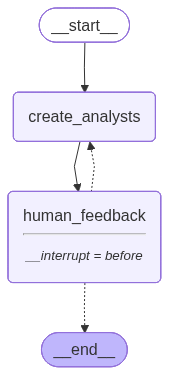

In [ ]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# 分析师生成指令模板
# 这个提示词指导AI如何根据研究主题创建合适的分析师团队
analyst_instructions="""你需要创建一组 AI 分析师人设。请严格遵循以下指引：

1. 先审阅研究主题：
{topic}

2. 查看（可选的）编辑反馈，它将指导分析师的人设创建：

{human_analyst_feedback}

3. 基于上述文档与/或反馈，识别最值得关注的主题。

4. 选出前 {max_analysts} 个主题。

5. 为每个主题分配一位分析师。"""

def create_analysts(state: GenerateAnalystsState):
    """
    创建分析师人设的核心函数
    
    功能:
        1. 根据研究主题和人类反馈生成分析师团队
        2. 使用结构化输出确保生成的分析师信息格式正确
        3. 将生成的分析师信息存储到状态中
    
    参数:
        state: 包含研究主题、分析师数量限制和人类反馈的状态对象
    
    返回:
        dict: 包含生成的分析师列表的字典
    """
    # 从状态中提取必要信息
    topic = state['topic']
    max_analysts = state['max_analysts']
    human_analyst_feedback = state.get('human_analyst_feedback', '')

    # 配置结构化输出，确保返回Perspectives格式的数据
    structured_llm = llm.with_structured_output(Perspectives)

    # 构建系统消息，包含研究主题、反馈和数量限制
    system_message = analyst_instructions.format(
        topic=topic,
        human_analyst_feedback=human_analyst_feedback,
        max_analysts=max_analysts
    )

    # 调用大模型生成分析师集合
    analysts = structured_llm.invoke([
        SystemMessage(content=system_message),
        HumanMessage(content="Generate the set of analysts.")
    ])

    # 将分析师列表写入状态，供后续节点使用
    return {"analysts": analysts.analysts}

def human_feedback(state: GenerateAnalystsState):
    """
    人机协同中断点节点
    
    功能:
        - 作为工作流的中断点，允许人类审查和修改生成的分析师
        - 这是一个空操作节点，主要用于流程控制
        - 人类可以在此节点提供反馈，系统会根据反馈重新生成分析师
    
    参数:
        state: 当前状态对象
    """
    pass

def should_continue(state: GenerateAnalystsState):
    """
    条件路由函数：决定工作流的下一步执行
    
    功能:
        - 检查是否有人类反馈
        - 如果有反馈，重新生成分析师
        - 如果没有反馈，结束流程
    
    参数:
        state: 当前状态对象
    
    返回:
        str: 下一个要执行的节点名称
    """
    # 检查是否有人类反馈
    human_analyst_feedback = state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"  # 有反馈，重新生成分析师

    # 没有反馈，结束流程
    return END

# 构建LangGraph工作流
builder = StateGraph(GenerateAnalystsState)

# 添加节点到工作流
builder.add_node("create_analysts", create_analysts)  # 分析师生成节点
builder.add_node("human_feedback", human_feedback)    # 人类反馈节点

# 添加边连接节点
builder.add_edge(START, "create_analysts")  # 开始 -> 生成分析师
builder.add_edge("create_analysts", "human_feedback")  # 生成分析师 -> 人类反馈

# 添加条件边：根据是否有反馈决定下一步
builder.add_conditional_edges(
    "human_feedback", 
    should_continue, 
    ["create_analysts", END]
)

# 编译工作流
memory = MemorySaver()  # 使用内存检查点保存状态
graph = builder.compile(
    interrupt_before=['human_feedback'],  # 在人类反馈节点前中断
    checkpointer=memory
)

# 显示工作流图
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [7]:
# Input
max_analysts = 3
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts,}, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Dr. Emily Carter
Affiliation: Tech Innovators Inc.
Role: Technology Analyst
Description: Focused on the technological advancements and integration capabilities of LangGraph as an agent framework. Interested in how LangGraph can enhance system interoperability and improve agent communication.
--------------------------------------------------
Name: Mr. James Thompson
Affiliation: Business Solutions Group
Role: Business Analyst
Description: Examines the business implications and strategic advantages of adopting LangGraph. Concerned with cost-effectiveness, scalability, and competitive edge provided by LangGraph.
--------------------------------------------------
Name: Ms. Sophia Nguyen
Affiliation: AI Ethics Consortium
Role: Ethics Analyst
Description: Investigates the ethical considerations and societal impacts of using LangGraph. Focuses on data privacy, security, and ethical AI deployment.
--------------------------------------------------


In [8]:
# Get state and look at next node
state = graph.get_state(thread)
state.next

('human_feedback',)

In [9]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback":
                            "Add in someone from a startup to add an entrepreneur perspective"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f08fbf1-7703-685e-8002-7aef62be3900'}}

In [10]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Dr. Emily Carter
Affiliation: Tech Innovators Inc.
Role: Technology Analyst
Description: Focused on the technological advancements and integration capabilities of LangGraph as an agent framework. Interested in how LangGraph can enhance system interoperability and improve agent communication.
--------------------------------------------------
Name: Mr. James Thompson
Affiliation: Business Solutions Group
Role: Business Analyst
Description: Examines the business implications and strategic advantages of adopting LangGraph. Concerned with cost-effectiveness, scalability, and competitive edge provided by LangGraph.
--------------------------------------------------
Name: Ms. Sophia Nguyen
Affiliation: AI Ethics Consortium
Role: Ethics Analyst
Description: Investigates the ethical considerations and societal impacts of using LangGraph. Focuses on data privacy, security, and ethical AI deployment.
--------------------------------------------------


Name: Alex Johnson
Affiliation: Tech Innovators Inc.
Role: Technical Analyst
Description: Alex is focused on the technical advantages and integration capabilities of LangGraph, emphasizing how it can streamline processes and enhance system interoperability.
--------------------------------------------------
Name: Jamie Lee
Affiliation: Greenfield Ventures
Role: Entrepreneurial Analyst
Description: Jamie provides insights from a startup perspective, focusing on the entrepreneurial benefits of adopting LangGraph, such as cost efficiency, scalability, and competitive advantage.
--------------------------------------------------
Name: Morgan Smith
Affiliation: Data Security Solutions
Role: Security Analyst
Description: Morgan is concerned with the security implications of using LangGraph, analyzing how it can improve data protection and compliance with industry standards.
--------------------------------------------------


In [11]:
# If we are satisfied, then we simply supply no feedback
further_feedack = None
graph.update_state(thread, {"human_analyst_feedback":
                            further_feedack}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f08fbf1-90dc-6f38-8004-c0498b5c4eb4'}}

In [12]:
# Continue the graph execution to end
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [13]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

In [14]:
final_state.next

()

In [15]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50)

Name: Alex Johnson
Affiliation: Tech Innovators Inc.
Role: Technical Analyst
Description: Alex is focused on the technical advantages and integration capabilities of LangGraph, emphasizing how it can streamline processes and enhance system interoperability.
--------------------------------------------------
Name: Jamie Lee
Affiliation: Greenfield Ventures
Role: Entrepreneurial Analyst
Description: Jamie provides insights from a startup perspective, focusing on the entrepreneurial benefits of adopting LangGraph, such as cost efficiency, scalability, and competitive advantage.
--------------------------------------------------
Name: Morgan Smith
Affiliation: Data Security Solutions
Role: Security Analyst
Description: Morgan is concerned with the security implications of using LangGraph, analyzing how it can improve data protection and compliance with industry standards.
--------------------------------------------------


## 进行访谈（Conduct Interview）

### 生成问题（Generate Question）

分析师将向专家提出问题。

In [ ]:
import operator
from typing import Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    """
    访谈状态管理类
    
    继承自MessagesState，用于管理分析师与专家之间的对话状态
    包含访谈过程中的所有必要信息和上下文
    """
    max_num_turns: int  # 对话轮次上限，控制访谈深度
    context: Annotated[list, operator.add]  # 检索到的源文档列表，使用operator.add进行累加
    analyst: Analyst  # 当前进行访谈的分析师对象
    interview: str  # 完整的访谈记录文本
    sections: list  # 访谈摘要小节列表，用于最终报告生成

class SearchQuery(BaseModel):
    """
    搜索查询数据模型
    
    用于结构化生成搜索查询，确保搜索请求格式正确
    """
    search_query: str = Field(None, description="用于检索的搜索查询语句")

In [ ]:
# 问题生成指令模板
# 指导AI分析师如何与专家进行有效的访谈对话
question_instructions = """你是一名分析师，需要通过访谈专家来了解一个具体主题。

你的目标是提炼与该主题相关的「有趣且具体」的洞见。

1. 有趣（Interesting）：让人感到意外或非显而易见的观点。

2. 具体（Specific）：避免泛泛而谈，包含专家提供的具体案例或细节。

以下是你的关注主题与目标设定：{goals}

请先用符合你人设的名字进行自我介绍，然后提出你的第一个问题。

持续追问，逐步深入，逐步完善你对该主题的理解。

当你认为信息已充分，请以这句话结束访谈：「Thank you so much for your help!」

请始终保持与你的人设与目标一致的说话方式。"""

def generate_question(state: InterviewState):
    """
    生成访谈问题的核心函数
    
    功能:
        1. 根据分析师的人设和当前对话历史生成下一个问题
        2. 确保问题符合分析师的关注点和角色定位
        3. 维护对话的连贯性和深度
    
    参数:
        state: 包含分析师信息和对话历史的状态对象
    
    返回:
        dict: 包含新生成问题的消息列表
    """
    # 从状态中获取分析师信息和当前对话历史
    analyst = state["analyst"]
    messages = state["messages"]

    # 构建系统消息，包含分析师的人设信息
    system_message = question_instructions.format(goals=analyst.persona)
    
    # 调用大模型生成下一个问题
    question = llm.invoke([SystemMessage(content=system_message)] + messages)

    # 将生成的问题添加到消息历史中
    return {"messages": [question]}

### 生成回答：并行化（Parallelization）

专家将并行地从多个来源收集信息来回答问题。

例如，我们可以使用：

- 具体网站（例如通过 [`WebBaseLoader`](https://python.langchain.com/v0.2/docs/integrations/document_loaders/web_base/) 抓取）
- 已建立索引的文档（例如基于 [RAG](https://python.langchain.com/v0.2/docs/tutorials/rag/) 的检索）
- Web 搜索
- 维基百科搜索

你也可以尝试不同的 Web 搜索工具，比如 [Tavily](https://tavily.com/)。

In [ ]:
def _set_env(var: str):
    """
    安全设置环境变量的辅助函数（重复定义，保持代码完整性）
    """
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

# 设置Tavily搜索API密钥
# Tavily是一个专门为AI应用优化的搜索API，提供高质量的搜索结果
_set_env("TAVILY_API_KEY")

TAVILY_API_KEY: ··········


In [ ]:
# 网络搜索工具配置
from langchain_community.tools.tavily_search import TavilySearchResults

# 初始化Tavily搜索工具
# max_results=3 限制每次搜索返回的结果数量，平衡信息丰富度和处理效率
tavily_search = TavilySearchResults(max_results=3)

/tmp/ipython-input-2338646555.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=3)


In [ ]:
# 维基百科搜索工具配置
from langchain_community.document_loaders import WikipediaLoader

接下来，我们将创建用于 Web 与维基百科检索的节点。

还会创建一个用于回答分析师问题的节点。

最后，创建用于保存完整访谈内容，以及撰写访谈摘要（“section”）的节点。

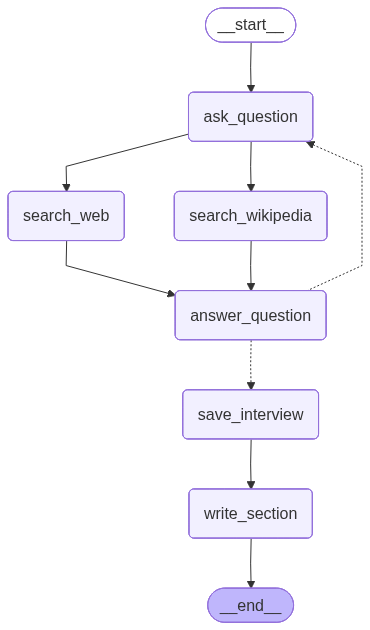

In [ ]:
from langchain_core.messages import get_buffer_string

# 搜索查询生成指令
# 指导AI如何从对话中提取有效的搜索查询
search_instructions = SystemMessage(content=f"""你将获得一段分析师与专家之间的对话。

你的目标是基于这段对话，为检索和/或 Web 搜索生成一条结构良好的查询语句。

首先，通读整段对话。

特别关注分析师最后提出的问题。

将这个最终问题转化为结构良好的 Web 搜索查询。""")

def search_web(state: InterviewState):
    """
    通过Web搜索检索相关文档
    
    功能:
        1. 分析当前对话内容，生成合适的搜索查询
        2. 使用Tavily API执行网络搜索
        3. 格式化搜索结果，便于后续处理
    
    参数:
        state: 包含对话历史的状态对象
    
    返回:
        dict: 包含格式化搜索结果的上下文信息
    """
    # 使用结构化输出生成搜索查询
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions] + state['messages'])

    # 执行Tavily网络搜索
    search_docs = tavily_search.invoke(search_query.search_query)

    # 格式化搜索结果，添加来源信息
    formatted_search_docs = "\n\n---\n\n".join([
        f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
        for doc in search_docs
    ])

    return {"context": [formatted_search_docs]}

def search_wikipedia(state: InterviewState):
    """
    通过维基百科检索相关文档
    
    功能:
        1. 分析当前对话内容，生成维基百科搜索查询
        2. 使用WikipediaLoader获取维基百科内容
        3. 格式化搜索结果，便于后续处理
    
    参数:
        state: 包含对话历史的状态对象
    
    返回:
        dict: 包含格式化维基百科搜索结果的上下文信息
    """
    # 使用结构化输出生成搜索查询
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions] + state['messages'])

    # 执行维基百科搜索，限制最多2个文档
    search_docs = WikipediaLoader(
        query=search_query.search_query,
        load_max_docs=2
    ).load()

    # 格式化维基百科搜索结果
    formatted_search_docs = "\n\n---\n\n".join([
        f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
        for doc in search_docs
    ])

    return {"context": [formatted_search_docs]}

# 专家回答指令模板
# 指导AI专家如何基于检索到的信息回答分析师的问题
answer_instructions = """你是一位被分析师访谈的专家。

以下是分析师的关注领域：{goals}。

你的目标是回答访谈者提出的问题。

回答问题时，请仅使用以下上下文：

{context}

回答须遵循如下要求：

1. 只使用上下文中提供的信息。

2. 不要引入上下文之外的信息，也不要做未在上下文明确说明的假设。

3. 上下文在每段文档顶部包含来源信息。

4. 在涉及具体论断时，请在相应内容旁标注引用来源编号。例如，针对来源 1 使用 [1]。

5. 在答案结尾处按顺序列出引用来源，如：[1] Source 1, [2] Source 2 等。

6. 若来源形如：<Document source="assistant/docs/llama3_1.pdf" page="7"/>，则在引用列表中只写：

[1] assistant/docs/llama3_1.pdf, page 7

并且不要再重复加中括号，也不要附加 Document source 前缀。"""

def generate_answer(state: InterviewState):
    """
    生成专家回答的核心函数
    
    功能:
        1. 基于检索到的上下文信息回答分析师的问题
        2. 确保回答符合专家的角色定位
        3. 提供准确的引用和来源信息
    
    参数:
        state: 包含分析师信息、对话历史和检索上下文的状态对象
    
    返回:
        dict: 包含专家回答的消息列表
    """
    # 从状态中获取必要信息
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # 构建系统消息，包含分析师关注点和检索上下文
    system_message = answer_instructions.format(
        goals=analyst.persona, 
        context=context
    )
    
    # 调用大模型生成专家回答
    answer = llm.invoke([SystemMessage(content=system_message)] + messages)

    # 标记该消息来自专家，便于后续路由
    answer.name = "expert"

    # 将专家回答添加到消息历史中
    return {"messages": [answer]}

def save_interview(state: InterviewState):
    """
    保存访谈内容的函数
    
    功能:
        1. 将完整的对话历史转换为文本格式
        2. 保存访谈记录，供后续报告生成使用
    
    参数:
        state: 包含对话历史的状态对象
    
    返回:
        dict: 包含完整访谈记录的字典
    """
    # 获取所有对话消息
    messages = state["messages"]

    # 将消息列表转换为格式化的字符串
    interview = get_buffer_string(messages)

    # 将访谈记录保存到状态中
    return {"interview": interview}

def route_messages(state: InterviewState, name: str = "expert"):
    """
    消息路由函数：决定访谈流程的下一步
    
    功能:
        1. 检查是否达到最大对话轮次
        2. 检查分析师是否表示访谈结束
        3. 决定是继续提问还是保存访谈
    
    参数:
        state: 当前访谈状态
        name: 专家消息的标识符，默认为"expert"
    
    返回:
        str: 下一个要执行的节点名称
    """
    # 获取对话消息和最大轮次设置
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns', 2)

    # 统计专家回答次数
    num_responses = len([
        m for m in messages 
        if isinstance(m, AIMessage) and m.name == name
    ])

    # 如果达到最大轮次，结束访谈
    if num_responses >= max_num_turns:
        return 'save_interview'

    # 检查上一个问题是否表明对话结束
    # 注意：这里假设倒数第二个消息是分析师的问题
    last_question = messages[-2]

    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    # 继续提问
    return "ask_question"

# 报告小节写作指令模板
# 指导AI如何将访谈内容转换为结构化的报告小节
section_writer_instructions = """你是一名资深技术写作者。

你的任务是基于一组来源文档，撰写一段简洁、易读的报告小节。

1. 先分析来源文档内容：
- 每个文档的名称在文档开头，以 <Document 标签呈现。

2. 使用 Markdown 制作小节结构：
- 用 ## 作为小节标题
- 用 ### 作为小节内的小标题

3. 按结构撰写：
 a. 标题（## 头）
 b. 摘要（### 头）
 c. 参考来源（### 头）

4. 标题需要贴合分析师的关注点并具有吸引力：
{focus}

5. 关于摘要部分：
- 先给出与分析师关注点相关的背景/上下文
- 强调访谈中获得的新颖、有趣或令人意外的洞见
- 使用到来源文档时，按使用顺序创建编号
- 不要提及访谈者或专家的名字
- 控制在约 400 字以内
- 在报告正文中使用数字引用（如 [1]、[2]），基于来源文档信息

6. 在参考来源部分：
- 列出报告中使用到的全部来源
- 给出完整链接或具体文档路径
- 每个来源单独一行；在行尾加两个空格以产生 Markdown 换行
- 参考格式：

### Sources
[1] 链接或文档名
[2] 链接或文档名

7. 合并重复来源。例如以下是不正确的：

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

应去重为：

[3] https://ai.meta.com/blog/meta-llama-3-1/

8. 最终检查：
- 确保报告结构符合要求
- 标题前不要有任何前言
- 检查是否遵循了全部规范"""

def write_section(state: InterviewState):
    """
    生成报告小节的核心函数
    
    功能:
        1. 基于访谈内容和检索到的文档生成结构化的报告小节
        2. 确保小节内容符合分析师的专业关注点
        3. 提供准确的引用和来源信息
    
    参数:
        state: 包含访谈记录、检索上下文和分析师信息的状态对象
    
    返回:
        dict: 包含生成的小节内容的字典
    """
    # 从状态中获取必要信息
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]

    # 构建系统消息，包含分析师的关注点描述
    system_message = section_writer_instructions.format(focus=analyst.description)
    
    # 调用大模型生成报告小节
    section = llm.invoke([
        SystemMessage(content=system_message),
        HumanMessage(content=f"Use this source to write your section: {context}")
    ])

    # 将生成的小节添加到状态中
    return {"sections": [section.content]}

# 构建访谈工作流
interview_builder = StateGraph(InterviewState)

# 添加各个功能节点
interview_builder.add_node("ask_question", generate_question)      # 生成问题节点
interview_builder.add_node("search_web", search_web)              # 网络搜索节点
interview_builder.add_node("search_wikipedia", search_wikipedia)  # 维基百科搜索节点
interview_builder.add_node("answer_question", generate_answer)    # 生成回答节点
interview_builder.add_node("save_interview", save_interview)      # 保存访谈节点
interview_builder.add_node("write_section", write_section)        # 撰写小节节点

# 定义工作流连接关系
interview_builder.add_edge(START, "ask_question")  # 开始 -> 提问
interview_builder.add_edge("ask_question", "search_web")  # 提问 -> 网络搜索
interview_builder.add_edge("ask_question", "search_wikipedia")  # 提问 -> 维基百科搜索
interview_builder.add_edge("search_web", "answer_question")  # 网络搜索 -> 回答
interview_builder.add_edge("search_wikipedia", "answer_question")  # 维基百科搜索 -> 回答

# 条件边：根据对话状态决定下一步
interview_builder.add_conditional_edges(
    "answer_question", 
    route_messages, 
    ['ask_question', 'save_interview']
)

interview_builder.add_edge("save_interview", "write_section")  # 保存访谈 -> 撰写小节
interview_builder.add_edge("write_section", END)  # 撰写小节 -> 结束

# 编译访谈工作流
memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

# 显示工作流图
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [22]:
# Pick one analyst
analysts[0]

Analyst(affiliation='Tech Innovators Inc.', name='Alex Johnson', role='Technical Analyst', description='Alex is focused on the technical advantages and integration capabilities of LangGraph, emphasizing how it can streamline processes and enhance system interoperability.')

此处我们运行一次访谈，并传入与主题相关的 llama3.1 论文索引作为参考。

In [ ]:
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "1"}}
interview = interview_graph.invoke({"analyst": analysts[0], "messages": messages, "max_num_turns": 2}, thread)
Markdown(interview['sections'][0])

### 并行访谈：Map-Reduce

我们通过 `Send()` API 并行运行每个访谈（map 步）。

随后在 reduce 步中将它们合并为报告主体。

### 收尾（Finalize）

最后增加一步，为最终报告写出引言与结论。

In [ ]:
import operator
from typing import List, Annotated
from typing_extensions import TypedDict

class ResearchGraphState(TypedDict):
    """
    研究图状态管理类
    
    用于管理整个研究流程的状态信息，包括分析师生成、并行访谈和报告生成
    这是整个研究助理系统的核心状态管理类
    """
    topic: str  # 研究主题
    max_analysts: int  # 分析师数量上限
    human_analyst_feedback: str  # 人类反馈信息
    analysts: List[Analyst]  # 分析师列表
    sections: Annotated[list, operator.add]  # 报告小节列表，使用operator.add进行累加
    introduction: str  # 最终报告的引言部分
    content: str  # 最终报告的主体内容
    conclusion: str  # 最终报告的结论部分
    final_report: str  # 完整的最终报告

In [ ]:
from langgraph.constants import Send

def initiate_all_interviews(state: ResearchGraphState):
    """
    启动所有并行访谈的Map步骤
    
    功能:
        1. 检查是否有人类反馈，如果有则重新生成分析师
        2. 如果没有反馈，则并行启动所有分析师的访谈流程
        3. 使用Send API实现真正的并行执行
    
    参数:
        state: 包含分析师列表和研究主题的状态对象
    
    返回:
        str 或 List[Send]: 如果有人类反馈返回节点名，否则返回Send对象列表
    """
    # 检查是否有人类反馈
    human_analyst_feedback = state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # 有人类反馈，重新生成分析师
        return "create_analysts"

    # 没有反馈，并行启动所有访谈
    else:
        topic = state["topic"]
        # 为每个分析师创建一个Send对象，实现并行执行
        return [
            Send("conduct_interview", {
                "analyst": analyst,
                "messages": [HumanMessage(
                    content=f"So you said you were writing an article on {topic}?"
                )]
            }) 
            for analyst in state["analysts"]
        ]

# 报告写作指令模板
# 指导AI如何将多个分析师的小节整合为统一的报告主体
report_writer_instructions = """你是一名技术写作者，正在为如下主题撰写报告：

{topic}

你拥有一支分析师团队。每位分析师完成了两件事：

1. 围绕一个具体子主题，访谈了一位专家。
2. 将发现写成一份备忘录（memo）。

你的任务：

1. 你将收到分析师们的备忘录集合。
2. 仔细思考每份备忘录的洞见。
3. 将它们整合为简洁的总体总结，串联起所有备忘录的中心观点。
4. 把每份备忘录的关键信息归纳成一个连贯的单一叙述。

报告格式要求：

1. 使用 Markdown 格式。
2. 报告不要有任何前言。
3. 不使用任何小标题。
4. 报告以一个标题开头：## Insights
5. 报告中不要提及任何分析师的名字。
6. 保留备忘录中的引用标注（如 [1]、[2]）。
7. 汇总最终来源列表，并以 `## Sources` 作为小节标题。
8. 按顺序列出来源且不要重复。

[1] Source 1
[2] Source 2

以下是分析师提供的备忘录，请基于此撰写报告：

{context}"""

def write_report(state: ResearchGraphState):
    """
    生成最终报告主体内容的函数（Reduce步骤）
    
    功能:
        1. 收集所有分析师的小节内容
        2. 将多个小节整合为统一的报告主体
        3. 确保报告结构清晰、内容连贯
    
    参数:
        state: 包含所有小节内容和研究主题的状态对象
    
    返回:
        dict: 包含报告主体内容的字典
    """
    # 获取所有小节内容和研究主题
    sections = state["sections"]
    topic = state["topic"]

    # 将所有小节拼接为完整文本
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    # 构建系统消息，包含研究主题和小节内容
    system_message = report_writer_instructions.format(
        topic=topic, 
        context=formatted_str_sections
    )
    
    # 调用大模型生成报告主体
    report = llm.invoke([
        SystemMessage(content=system_message),
        HumanMessage(content=f"Write a report based upon these memos.")
    ])
    
    return {"content": report.content}

# 引言和结论写作指令模板
# 指导AI如何为报告生成简洁有力的引言和结论
intro_conclusion_instructions = """你是一名技术写作者，正在完成主题为 {topic} 的报告。

你将获得报告的全部小节。

你的任务是撰写简洁而有说服力的引言或结论。

由用户告知写引言还是结论。

两者均不需要任何前言。

目标约 100 字：
- 引言：精炼预览各小节要点
- 结论：精炼回顾各小节要点

使用 Markdown 格式。

引言要求：创建一个有吸引力的标题，并用 # 作为标题头。

引言小节标题使用：## Introduction

结论小节标题使用：## Conclusion

撰写时可参考以下小节内容：{formatted_str_sections}"""

def write_introduction(state: ResearchGraphState):
    """
    生成报告引言的函数
    
    功能:
        1. 基于所有小节内容生成报告引言
        2. 提供报告的整体概览和吸引力
        3. 为读者提供阅读指导
    
    参数:
        state: 包含所有小节内容和研究主题的状态对象
    
    返回:
        dict: 包含引言内容的字典
    """
    # 获取所有小节内容和研究主题
    sections = state["sections"]
    topic = state["topic"]

    # 将所有小节拼接为完整文本
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    # 构建指令，包含研究主题和小节内容
    instructions = intro_conclusion_instructions.format(
        topic=topic, 
        formatted_str_sections=formatted_str_sections
    )
    
    # 调用大模型生成引言
    intro = llm.invoke([
        instructions,
        HumanMessage(content=f"Write the report introduction")
    ])
    
    return {"introduction": intro.content}

def write_conclusion(state: ResearchGraphState):
    """
    生成报告结论的函数
    
    功能:
        1. 基于所有小节内容生成报告结论
        2. 总结报告的主要发现和洞察
        3. 为读者提供清晰的总结
    
    参数:
        state: 包含所有小节内容和研究主题的状态对象
    
    返回:
        dict: 包含结论内容的字典
    """
    # 获取所有小节内容和研究主题
    sections = state["sections"]
    topic = state["topic"]

    # 将所有小节拼接为完整文本
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    # 构建指令，包含研究主题和小节内容
    instructions = intro_conclusion_instructions.format(
        topic=topic, 
        formatted_str_sections=formatted_str_sections
    )
    
    # 调用大模型生成结论
    conclusion = llm.invoke([
        instructions,
        HumanMessage(content=f"Write the report conclusion")
    ])
    
    return {"conclusion": conclusion.content}

def finalize_report(state: ResearchGraphState):
    """
    最终报告生成函数（Reduce步骤的最终阶段）
    
    功能:
        1. 整合引言、主体内容和结论
        2. 处理来源信息的格式
        3. 生成完整的最终报告
    
    参数:
        state: 包含引言、主体内容、结论和来源信息的状态对象
    
    返回:
        dict: 包含完整最终报告的字典
    """
    # 获取报告主体内容
    content = state["content"]
    
    # 清理内容格式，移除重复的标题
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    
    # 分离主体内容和来源信息
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    # 组合完整的最终报告
    final_report = (
        state["introduction"] + 
        "\n\n---\n\n" + 
        content + 
        "\n\n---\n\n" + 
        state["conclusion"]
    )
    
    # 如果有来源信息，添加到报告末尾
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    
    return {"final_report": final_report}

# 构建完整的研究图工作流
builder = StateGraph(ResearchGraphState)

# 添加所有功能节点
builder.add_node("create_analysts", create_analysts)  # 分析师生成节点
builder.add_node("human_feedback", human_feedback)    # 人类反馈节点
builder.add_node("conduct_interview", interview_builder.compile())  # 访谈子图节点
builder.add_node("write_report", write_report)        # 报告主体写作节点
builder.add_node("write_introduction", write_introduction)  # 引言写作节点
builder.add_node("write_conclusion", write_conclusion)      # 结论写作节点
builder.add_node("finalize_report", finalize_report)        # 最终报告生成节点

# 定义工作流连接关系
builder.add_edge(START, "create_analysts")  # 开始 -> 生成分析师
builder.add_edge("create_analysts", "human_feedback")  # 生成分析师 -> 人类反馈

# 条件边：根据是否有反馈决定下一步
builder.add_conditional_edges(
    "human_feedback", 
    initiate_all_interviews, 
    ["create_analysts", "conduct_interview"]
)

# 并行执行：访谈完成后同时进行报告写作、引言写作和结论写作
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")

# 等待所有写作任务完成后，进行最终报告生成
builder.add_edge(
    ["write_conclusion", "write_report", "write_introduction"], 
    "finalize_report"
)
builder.add_edge("finalize_report", END)  # 最终报告生成 -> 结束

# 编译完整的研究图工作流
memory = MemorySaver()
graph = builder.compile(
    interrupt_before=['human_feedback'],  # 在人类反馈节点前中断
    checkpointer=memory
)

# 显示完整的工作流图
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

我们来就 LangGraph 提一个开放式问题。

In [ ]:
# 演示：运行研究助理系统
# 设置输入参数
max_analysts = 3  # 分析师数量
topic = "The benefits of adopting LangGraph as an agent framework"  # 研究主题
thread = {"configurable": {"thread_id": "1"}}  # 线程ID，用于状态管理

# 运行工作流直到第一个中断点（人类反馈节点）
for event in graph.stream({
    "topic": topic,
    "max_analysts": max_analysts
}, thread, stream_mode="values"):
    
    # 检查是否有分析师信息输出
    analysts = event.get('analysts', '')
    if analysts:
        # 显示生成的分析师信息
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

In [ ]:
# 模拟人类反馈：添加一个AI原生初创公司的CEO视角
# 这展示了人机协同（Human-in-the-loop）功能的使用
graph.update_state(thread, {
    "human_analyst_feedback": "Add in the CEO of gen ai native startup"
}, as_node="human_feedback")

In [ ]:
# 检查更新后的分析师列表
# 系统会根据人类反馈重新生成分析师团队
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        # 显示更新后的分析师信息
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

In [ ]:
# 确认满意当前的分析师团队，继续执行后续流程
# 设置反馈为None表示没有进一步的修改需求
graph.update_state(thread, {
    "human_analyst_feedback": None
}, as_node="human_feedback")

In [ ]:
# 继续执行完整的研究流程
# 包括并行访谈、报告生成等所有后续步骤
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [ ]:
from IPython.display import Markdown

# 获取最终状态并显示生成的报告
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')

# 使用Markdown格式显示最终报告
Markdown(report)

# LangSmith执行追踪

我们可以查看一次完整的执行追踪（trace），了解整个研究流程的详细执行情况：

`https://smith.langchain.com/public/2933a7bb-bcef-4d2d-9b85-cc735b22ca0c/r`

## 追踪内容说明

这个追踪链接展示了：

1. **分析师生成过程**：如何根据研究主题创建不同的分析师角色
2. **并行访谈执行**：多个分析师同时进行访谈的详细过程
3. **信息检索流程**：网络搜索和维基百科搜索的具体执行
4. **报告生成步骤**：从访谈内容到最终报告的完整转换过程
5. **人机协同交互**：人类反馈如何影响系统行为

通过这个追踪，你可以深入了解LangGraph工作流的内部执行机制和每个节点的具体功能。